# ECG Arrhythmia Classification

In [ ]:
from google.colab import ai
response = ai.generate_text("What are different types of cardiac arrhythmias, and why their automatic prediction is important? What are specific types of arrhythmias present in Physionet's MIT-BIH Arrhythmia dataset?")
response

In [ ]:
'''Follow this cell sequentially, if you want to run the code in this notebook on your local machine. It will set up a new python environment and install the necessary packages. Make sure to activate the environment before running the notebook.

   AND you can ignore this, if you use Colab/Kaggle platform.
'''

### Make a new local python environment and install the required packages using the command below. This will ensure that you have all the necessary dependencies to run the code in this notebook.
#!python3 -m venv myenv
## source myenv/bin/activate
### Initiate a jupyter kernel
# !pip install ipykernel
# !python3 -m ipykernel install --user --name=myenv
# !pip install -r requirements.txt

In [ ]:
## Load data (use Kaggle preprocessed or your own)
## Example: download from https://www.kaggle.com/shayanfazeli/heartbeat

In [2]:
!pip install shap -qq

In [3]:
!unzip archive.zip -d data/

Archive:  archive.zip
  inflating: data/mitbih_test.csv    
  inflating: data/mitbih_train.csv   
  inflating: data/ptbdb_abnormal.csv  
  inflating: data/ptbdb_normal.csv   


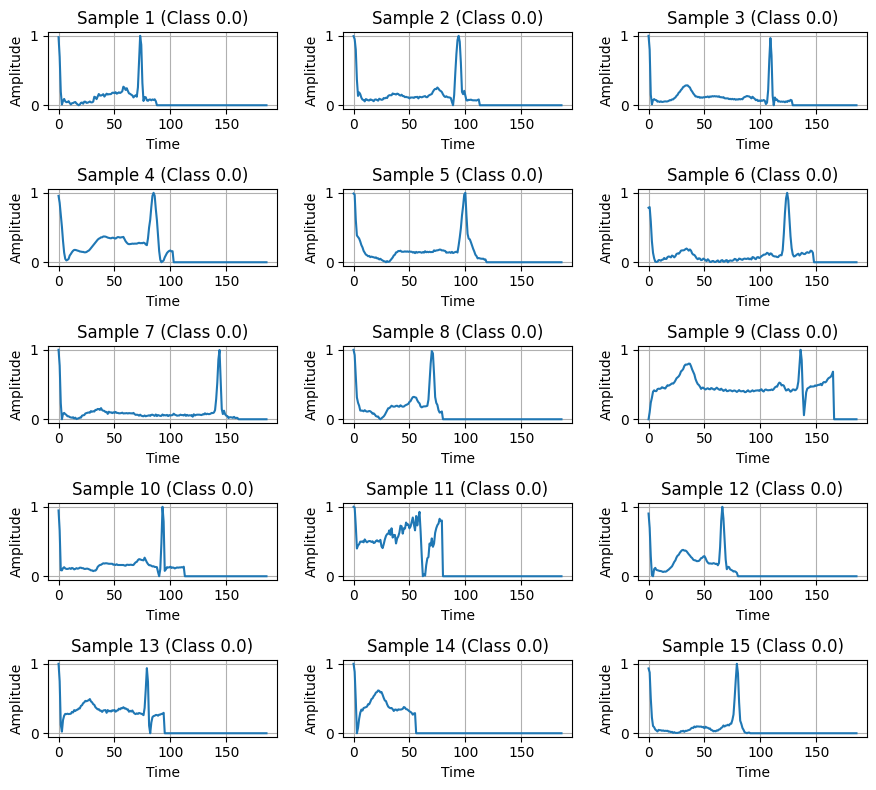

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
data_path = "../data/mitbih_test.csv"
df = pd.read_csv(data_path, header=None)
df.head()
# The dataset contains 187 samples and 188 columns. The first 187 columns represent the ECG signal, and the last column (column 187) represents the class label for each sample.
# The class labels are as follows:
# 0: Normal beat
# 1: Supraventricular ectopic beat
# 2: Ventricular ectopic beat
# 3: Fusion beat
# 4: Unknown beat
# The dataset is imbalanced, with the majority of samples belonging to the normal beat class (class 0). 
# This imbalance can pose challenges for machine learning models, as they may be biased towards the majority class. 
# It is important to consider techniques for handling imbalanced datasets, such as resampling or using appropriate evaluation metrics, when developing models for this dataset.
# The dataset is commonly used for research in the field of cardiac arrhythmia detection and classification. 
# Researchers often use it to develop and evaluate machine learning models for automatic arrhythmia detection, 
# which can assist in clinical diagnosis and monitoring of patients with heart conditions.
plt.figure(figsize=(9, 8))
for i in range(15):
    plt.subplot(5, 3, i + 1)
    plt.plot(df.iloc[200+i, :-1])  # Plot the ECG signal for each sample
    plt.title(f"Sample {i + 1} (Class {df.iloc[200+i, -1]})")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# import tensorflow as tf
# import sys

# # 1. Check if MPS is available
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
# print("TensorFlow version:", tf.__version__)

# # Detect and configure GPU (MPS on Apple Silicon)
# gpus = tf.config.list_physical_devices('GPU')

# if gpus:
#     try:
#         # Use the first (and usually only) GPU
#         tf.config.set_visible_devices(gpus[0], 'GPU')
#         # Enable memory growth (recommended on Apple Silicon)
#         tf.config.experimental.set_memory_growth(gpus[0], True)
#         print("→ Using MPS GPU acceleration")
#     except RuntimeError as e:
#         print("→ GPU configuration failed:", e)
#         print("→ Falling back to CPU")
# else:
#     print("→ No GPU (MPS) detected → using CPU")

# # Quick confirmation
# print("Is GPU available?", tf.test.is_gpu_available())
# print("Current devices:", tf.config.list_logical_devices())

# # Optional: force a small operation on GPU to verify
# with tf.device('/GPU:0' if gpus else '/CPU:0'):
#     a = tf.random.normal([1000, 1000])
#     b = tf.random.normal([1000, 1000])
#     c = tf.matmul(a, b)
#     print("Matrix multiplication device:", c.device)
# # print(c)

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loading MIT-BIH dataset from Kaggle
Sampling frequency: 125 Hz
Heartbeat length: 187 samples (from CSV)

Train CSV shape: (87554, 188) (should be 87554 rows × 188 columns)
Test CSV shape: (21892, 188) (should be 21892 rows × 188 columns)

Extracted shapes:
X_train: (87554, 187)
X_test: (21892, 187)
Train class distribution: [72471  2223  5788   641  6431]
Test class distribution: [18118   556  1448   162  1608]

Bandpass filter parameters (0.5-45 Hz):
Nyquist: 62.5 Hz
Low cutoff normalized: 0.0080
High cutoff normalized: 0.7200
Applying bandpass filter...

Extracting handcrafted features...
Train features shape: (87554, 6)
Test features shape: (21892, 6)

Normalizing signals...
X_train_norm shape: (87554, 187)
X_train_norm mean: 0.000000
X_train_norm std: 1.000000

Normalizing features...
Train features normalized shape: (87554, 6)
Test features normalized shape: (21892, 6)

Fin

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ signal_input        │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 187, 32)   │        512 │ signal_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 187, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 187, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 93, 32)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 93, 64)    │     22,592 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 93, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 93, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 93, 64)    │     45,120 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 93, 64)    │      2,112 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 93, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 93, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 46, 64)    │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 46, 128)   │     57,472 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 46, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 46, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 46, 128)   │          0 │ activation_3[0][

 Total params: 1,610,021 (6.14 MB)

 Trainable params: 1,607,333 (6.13 MB)

...

6040/6040 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - accuracy: 0.9984 - f1_score: 0.9983 - loss: 0.4136 - sensitivity: 0.9977 - specificity: 0.9997 - val_accuracy: 0.9983 - val_f1_score: 0.9982 - val_loss: 0.4042 - val_sensitivity: 0.9980 - val_specificity: 0.9996 - learning_rate: 5.0000e-04
Epoch 66/100
6037/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9985 - f1_score: 0.9984 - loss: 0.4132 - sensitivity: 0.9978 - specificity: 0.9998
Epoch 66: val_f1_score did not improve from 0.99825
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - accuracy: 0.9985 - f1_score: 0.9984 - loss: 0.4132 - sensitivity: 0.9978 - specificity: 0.9998 - val_accuracy: 0.9981 - val_f1_score: 0.9981 - val_loss: 0.4055 - val_sensitivity: 0.9977 - val_specificity: 0.9996 - learning_rate: 5.0000e-04
Epoch 67/100
6036/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9983 - f1_score: 0.9982 - loss: 0.4138 - sensitivity: 0.9976 - specificity: 0.9997
Epoch 67: val_f1_score did not improve from 0.99825
6040/6040 ━━━━━━

6040/6040 ━━━━━━━━━━━━━━━━━━━━ 63s 10ms/step - accuracy: 0.9993 - f1_score: 0.9992 - loss: 0.4091 - sensitivity: 0.9990 - specificity: 0.9999 - val_accuracy: 0.9985 - val_f1_score: 0.9985 - val_loss: 0.3992 - val_sensitivity: 0.9983 - val_specificity: 0.9997 - learning_rate: 2.5000e-04
Epoch 85/100
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9994 - f1_score: 0.9993 - loss: 0.4067 - sensitivity: 0.9991 - specificity: 0.9999
Epoch 85: val_f1_score did not improve from 0.99847
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - accuracy: 0.9994 - f1_score: 0.9993 - loss: 0.4067 - sensitivity: 0.9991 - specificity: 0.9999 - val_accuracy: 0.9985 - val_f1_score: 0.9985 - val_loss: 0.3986 - val_sensitivity: 0.9982 - val_specificity: 0.9997 - learning_rate: 2.5000e-04
Epoch 86/100
6037/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9994 - f1_score: 0.9993 - loss: 0.4061 - sensitivity: 0.9991 - specificity: 0.9999
Epoch 86: val_f1_score did not improve from 0.99847
6040/6040 ━━━━━━

6040/6040 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - accuracy: 0.9993 - f1_score: 0.9993 - loss: 0.4060 - sensitivity: 0.9990 - specificity: 0.9999 - val_accuracy: 0.9987 - val_f1_score: 0.9987 - val_loss: 0.3982 - val_sensitivity: 0.9985 - val_specificity: 0.9997 - learning_rate: 2.5000e-04
Epoch 88/100
6035/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9995 - f1_score: 0.9994 - loss: 0.4057 - sensitivity: 0.9991 - specificity: 0.9999
Epoch 88: val_f1_score did not improve from 0.99869
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - accuracy: 0.9995 - f1_score: 0.9994 - loss: 0.4057 - sensitivity: 0.9991 - specificity: 0.9999 - val_accuracy: 0.9983 - val_f1_score: 0.9984 - val_loss: 0.3985 - val_sensitivity: 0.9982 - val_specificity: 0.9996 - learning_rate: 2.5000e-04
Epoch 89/100
6035/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9994 - f1_score: 0.9993 - loss: 0.4057 - sensitivity: 0.9991 - specificity: 0.9999
Epoch 89: val_f1_score did not improve from 0.99869
6040/6040 ━━━━━━

6040/6040 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - accuracy: 0.9994 - f1_score: 0.9994 - loss: 0.4055 - sensitivity: 0.9991 - specificity: 0.9999 - val_accuracy: 0.9988 - val_f1_score: 0.9988 - val_loss: 0.3972 - val_sensitivity: 0.9987 - val_specificity: 0.9997 - learning_rate: 2.5000e-04
Epoch 99/100
6035/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9994 - f1_score: 0.9993 - loss: 0.4055 - sensitivity: 0.9991 - specificity: 0.9999
Epoch 99: val_f1_score did not improve from 0.99881
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - accuracy: 0.9994 - f1_score: 0.9993 - loss: 0.4055 - sensitivity: 0.9991 - specificity: 0.9999 - val_accuracy: 0.9984 - val_f1_score: 0.9984 - val_loss: 0.3985 - val_sensitivity: 0.9981 - val_specificity: 0.9996 - learning_rate: 2.5000e-04
Epoch 100/100
6035/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9995 - f1_score: 0.9994 - loss: 0.4052 - sensitivity: 0.9992 - specificity: 0.9999
Epoch 100: val_f1_score did not improve from 0.99881
6040/6040 ━━━━


✅ Model saved as 'ecg_model_final_125Hz.h5'

EVALUATION ON TEST SET

Test Results:
Loss: 0.4348
Accuracy: 0.9851
Sensitivity: 0.9839
Specificity: 0.9966
F1-Score: 0.9850

Detailed Classification Report:
              precision    recall  f1-score   support

           N     0.9904    0.9941    0.9922     18118
           S     0.8764    0.8165    0.8454       556
           V     0.9690    0.9503    0.9596      1448
           F     0.7953    0.8395    0.8168       162
           Q     0.9950    0.9882    0.9916      1608

    accuracy                         0.9851     21892
   macro avg     0.9252    0.9177    0.9211     21892
weighted avg     0.9850    0.9851    0.9850     21892



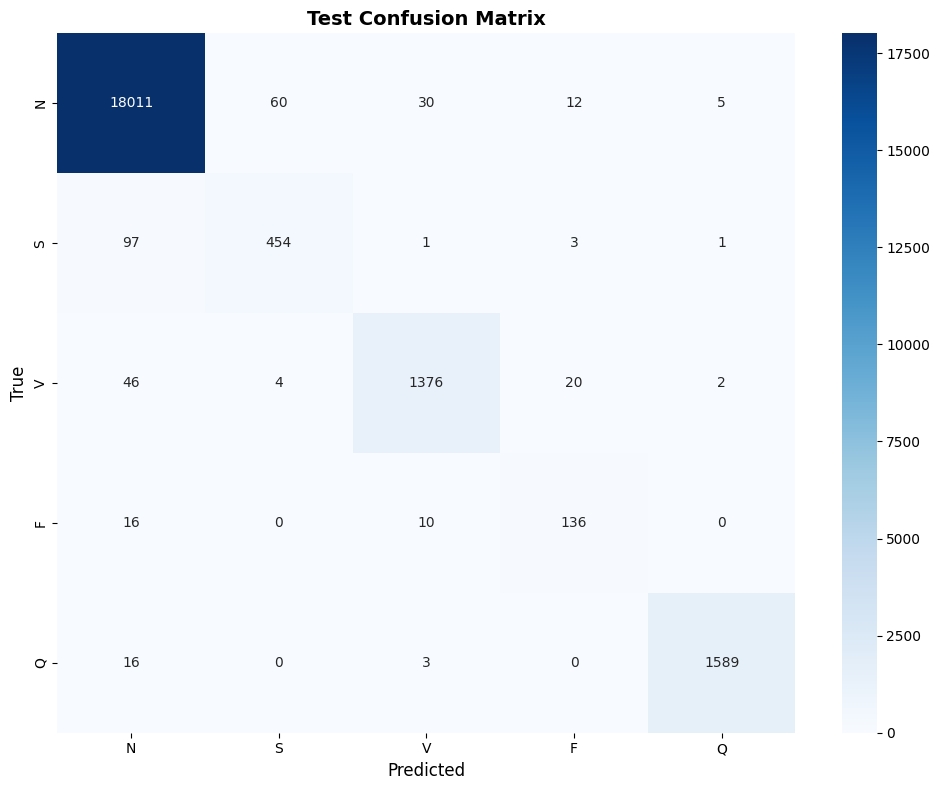

Weighted ROC-AUC: 0.9885

Per-Class Performance:
N: Accuracy = 0.9871
S: Accuracy = 0.9924
V: Accuracy = 0.9947
F: Accuracy = 0.9972
Q: Accuracy = 0.9988


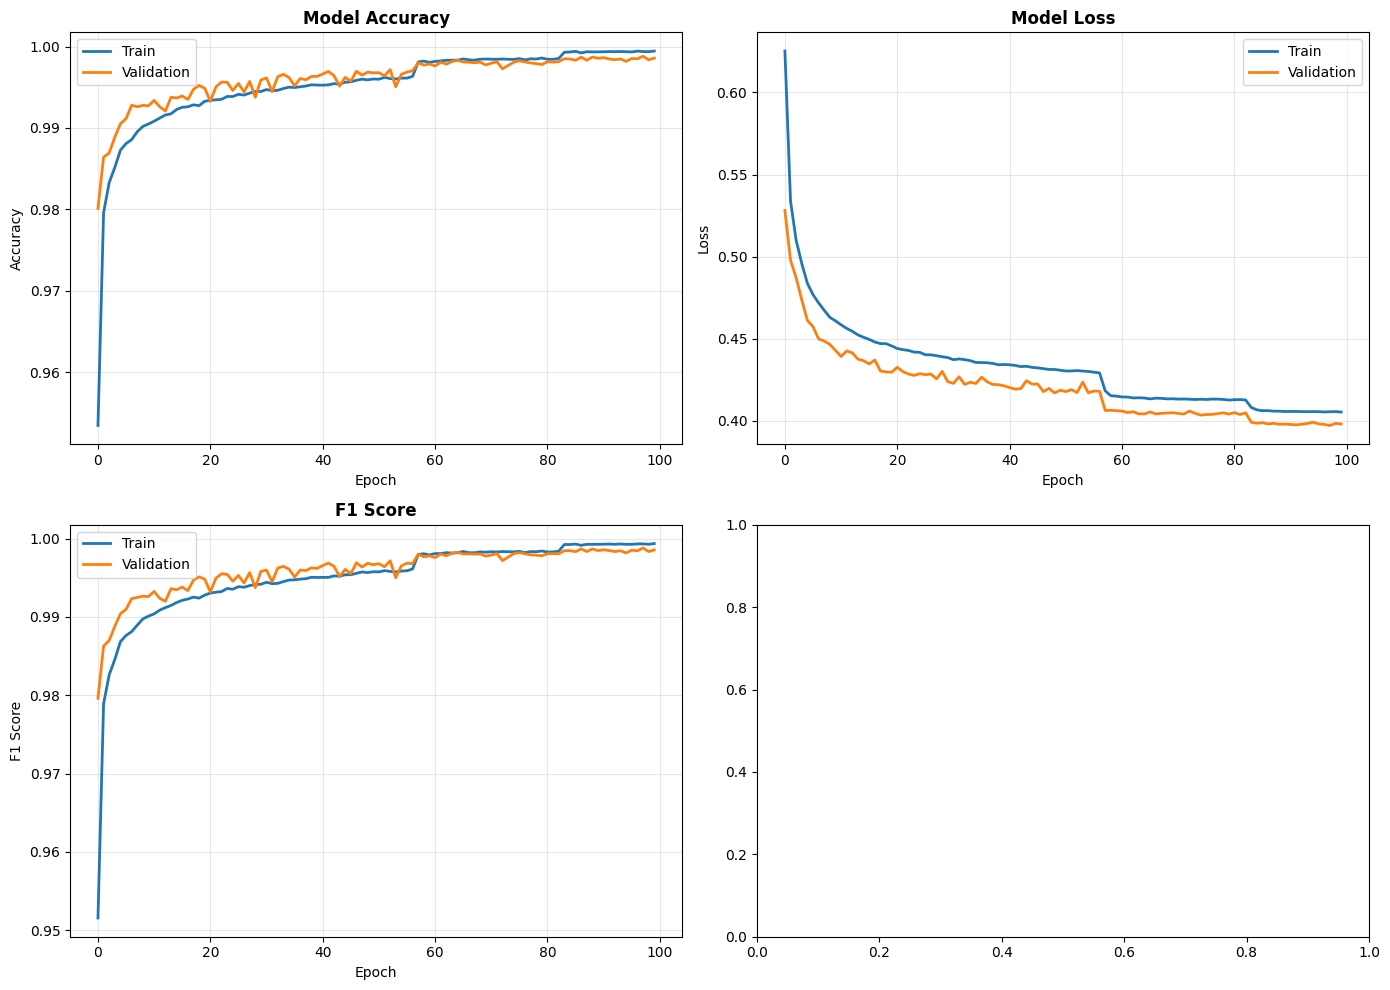

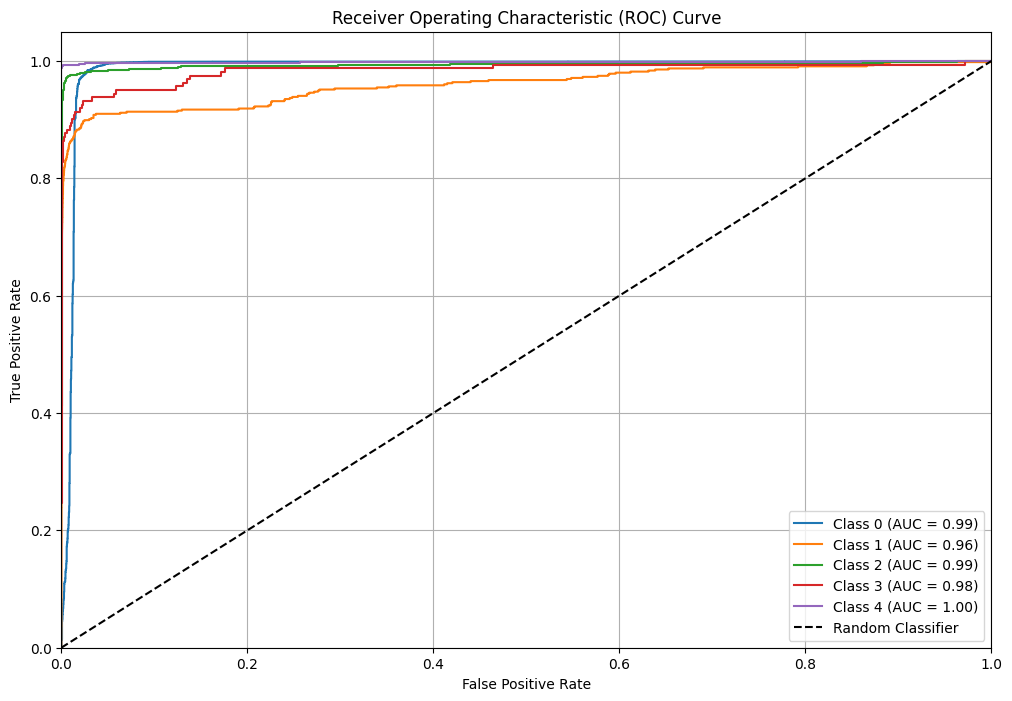

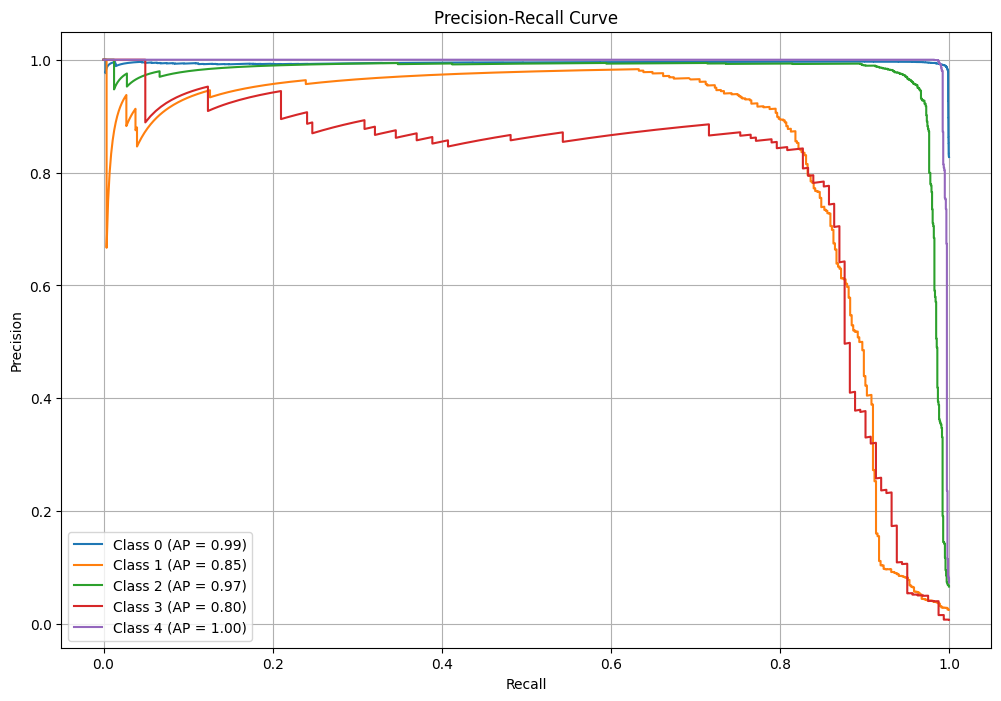


Total misclassified samples: 326


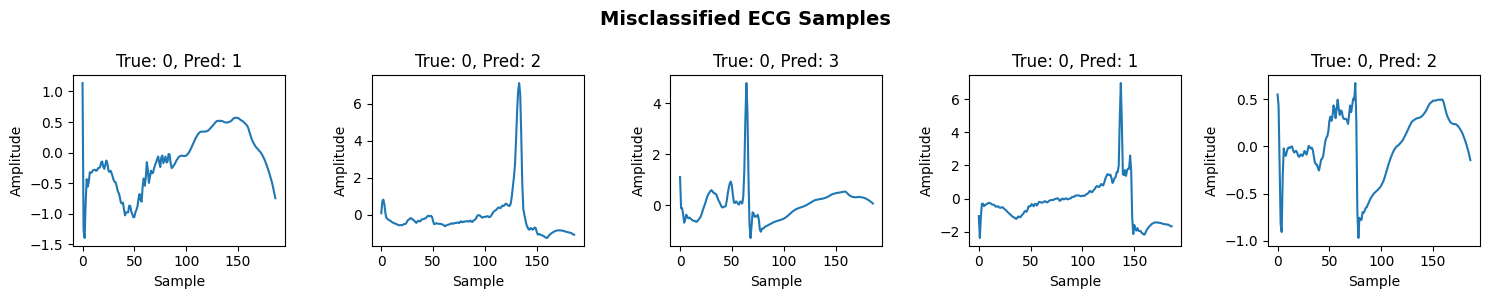


CALIBRATION ANALYSIS

CALIBRATION ANALYSIS REPORT

📊 Expected Calibration Error (ECE): 0.024786
   → Well calibrated

📈 Brier Scores (lower is better, range 0-1):
   → Overall Brier Score: 0.006095
   → N (Normal): 0.014388
   → S (Supraventricular): 0.006764
   → V (Ventricular): 0.004973
   → F (Fusion): 0.002587
   → Q (Unknown): 0.001764

🔍 Confidence Statistics:
   → Mean confidence: 0.9238
   → Median confidence: 0.9301
   → Std confidence: 0.0375
   → % High confidence (>0.9): 97.04%

📊 Confidence by Predicted Class:
   → N (Normal): mean=0.9267, median=0.9304, n=18186
   → S (Supraventricular): mean=0.8942, median=0.9338, n=518
   → V (Ventricular): mean=0.9124, median=0.9243, n=1420
   → F (Fusion): mean=0.8873, median=0.9203, n=171
   → Q (Unknown): mean=0.9148, median=0.9177, n=1597


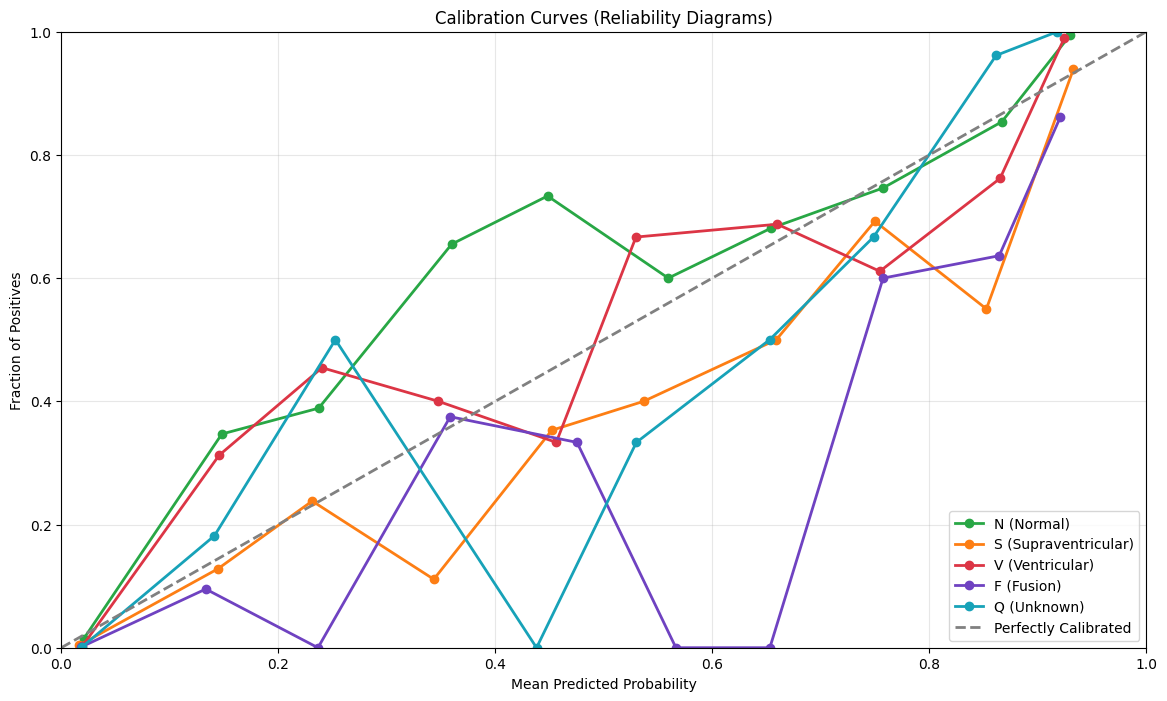

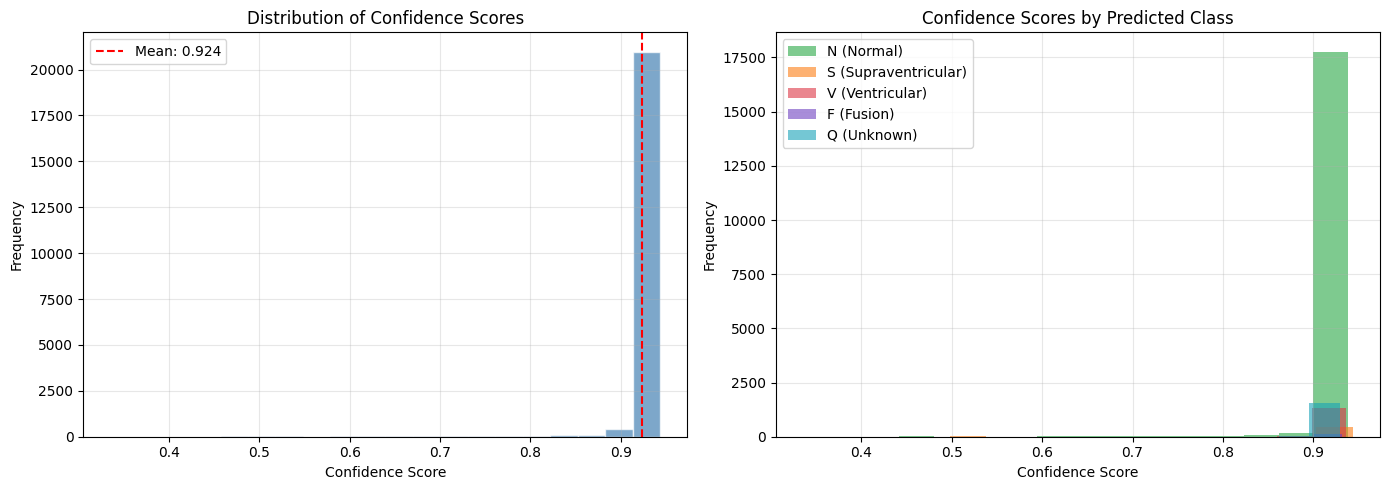


INTERPRETABILITY ANALYSIS

Generating saliency maps for correctly classified examples...


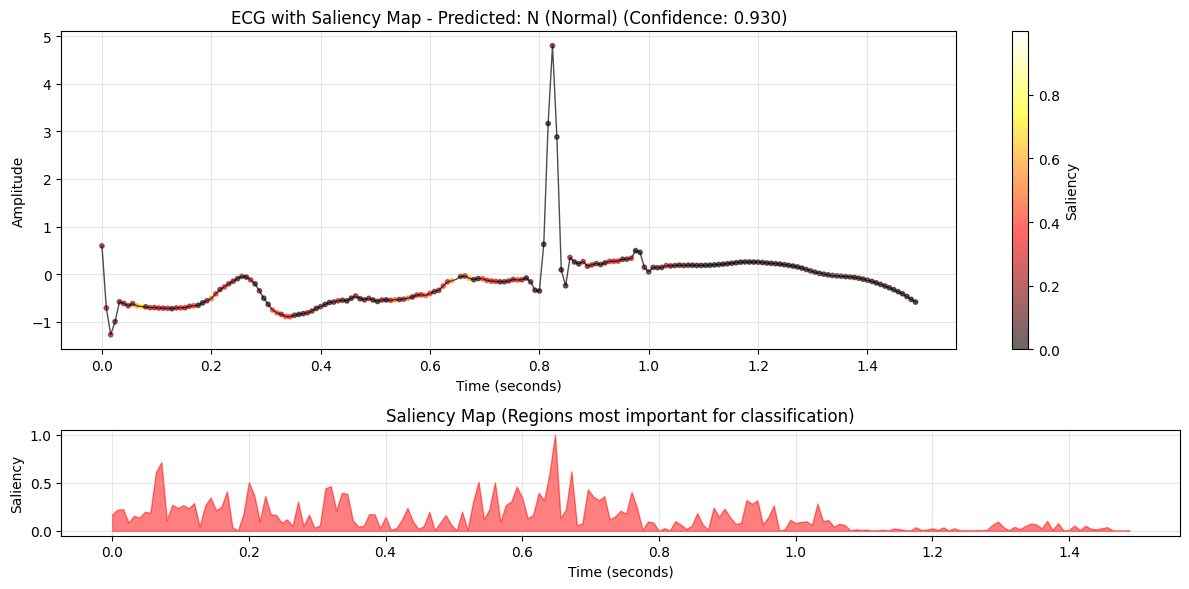

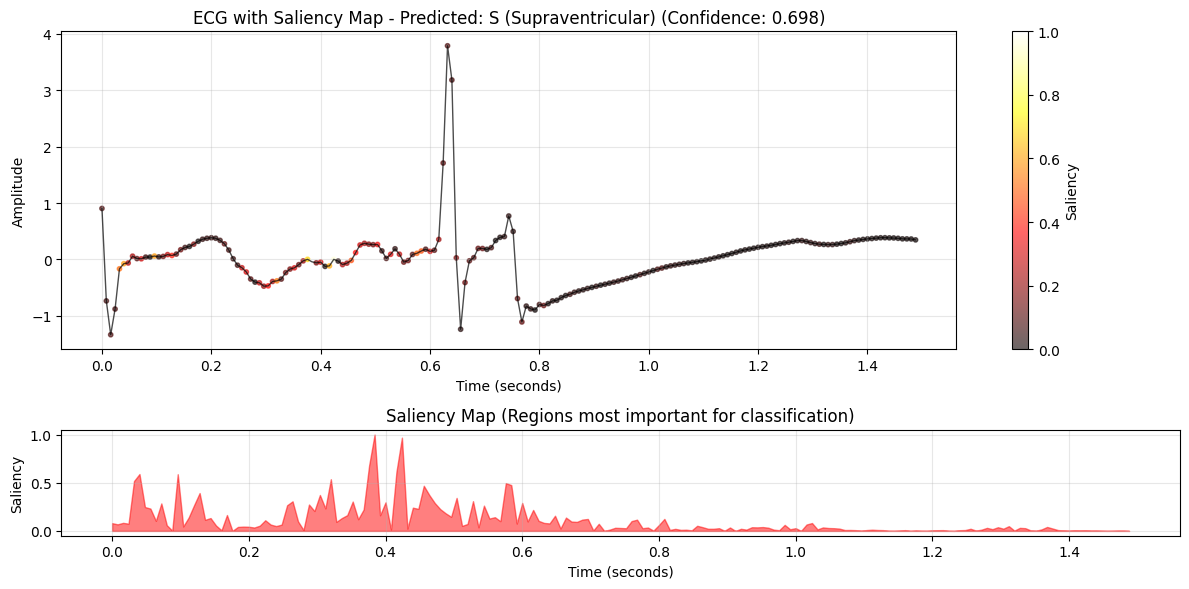

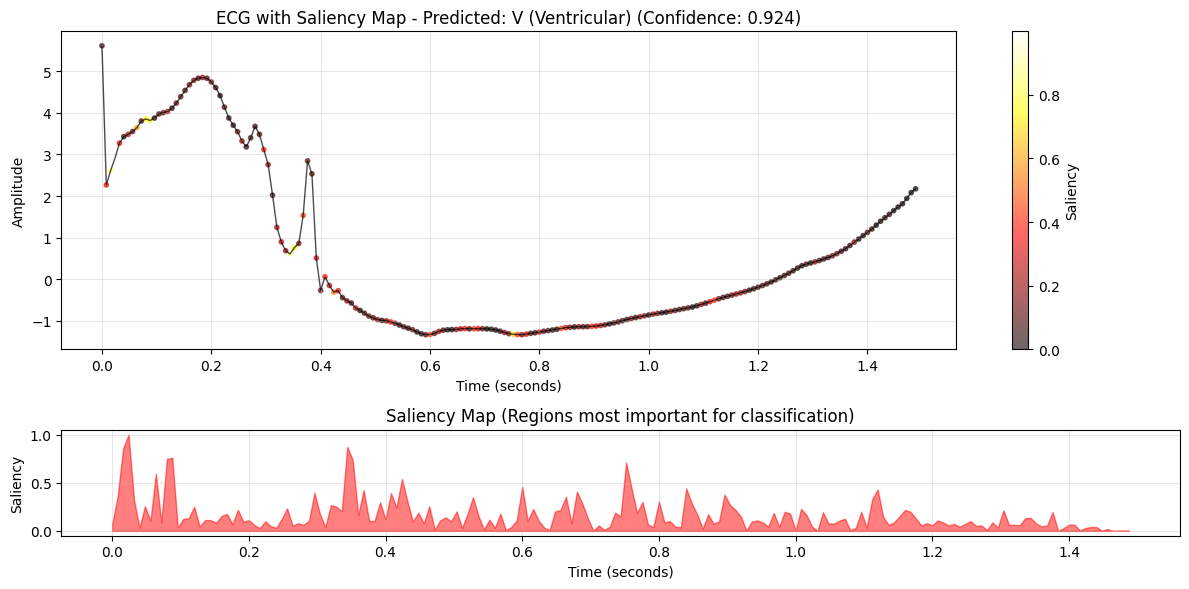

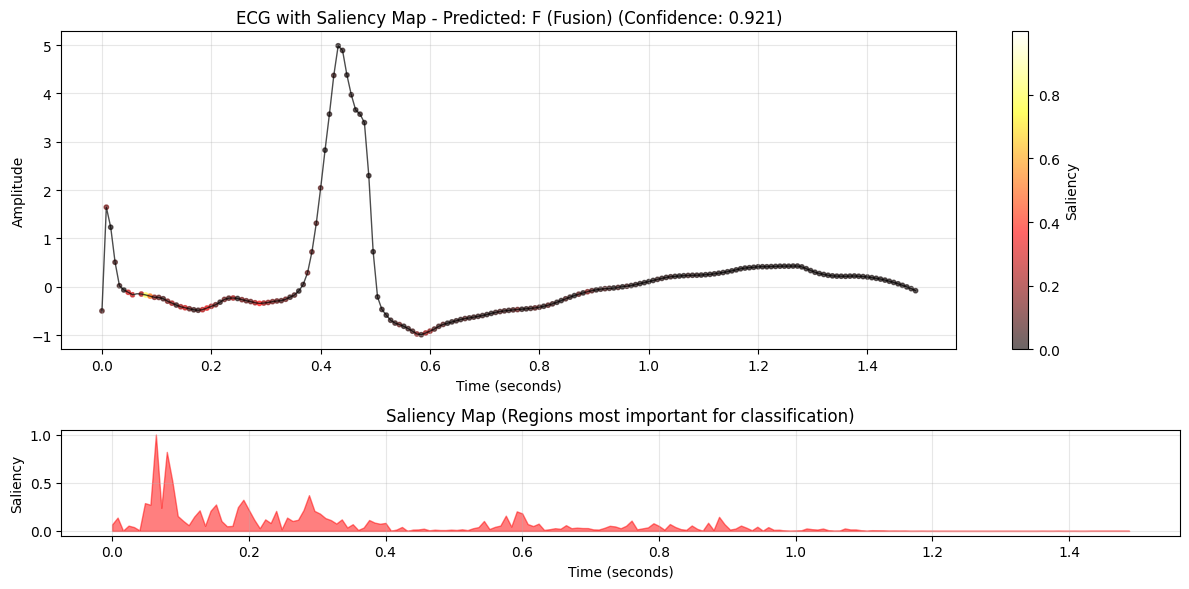

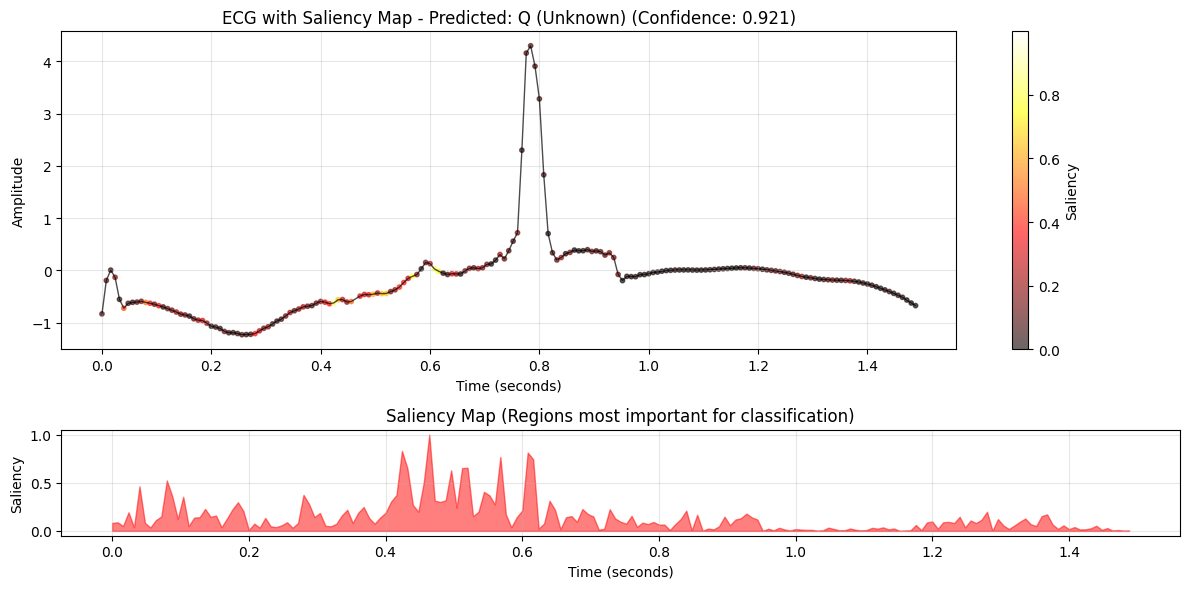


MISCLASSIFICATION ANALYSIS WITH SALIENCY MAPS
Total misclassified samples: 326

Most common confusion patterns:
  N (Normal) → S (Supraventricular): 55 samples
  N (Normal) → V (Ventricular): 29 samples
  N (Normal) → F (Fusion): 11 samples
  N (Normal) → Q (Unknown): 5 samples

Generating saliency maps for 5 examples...


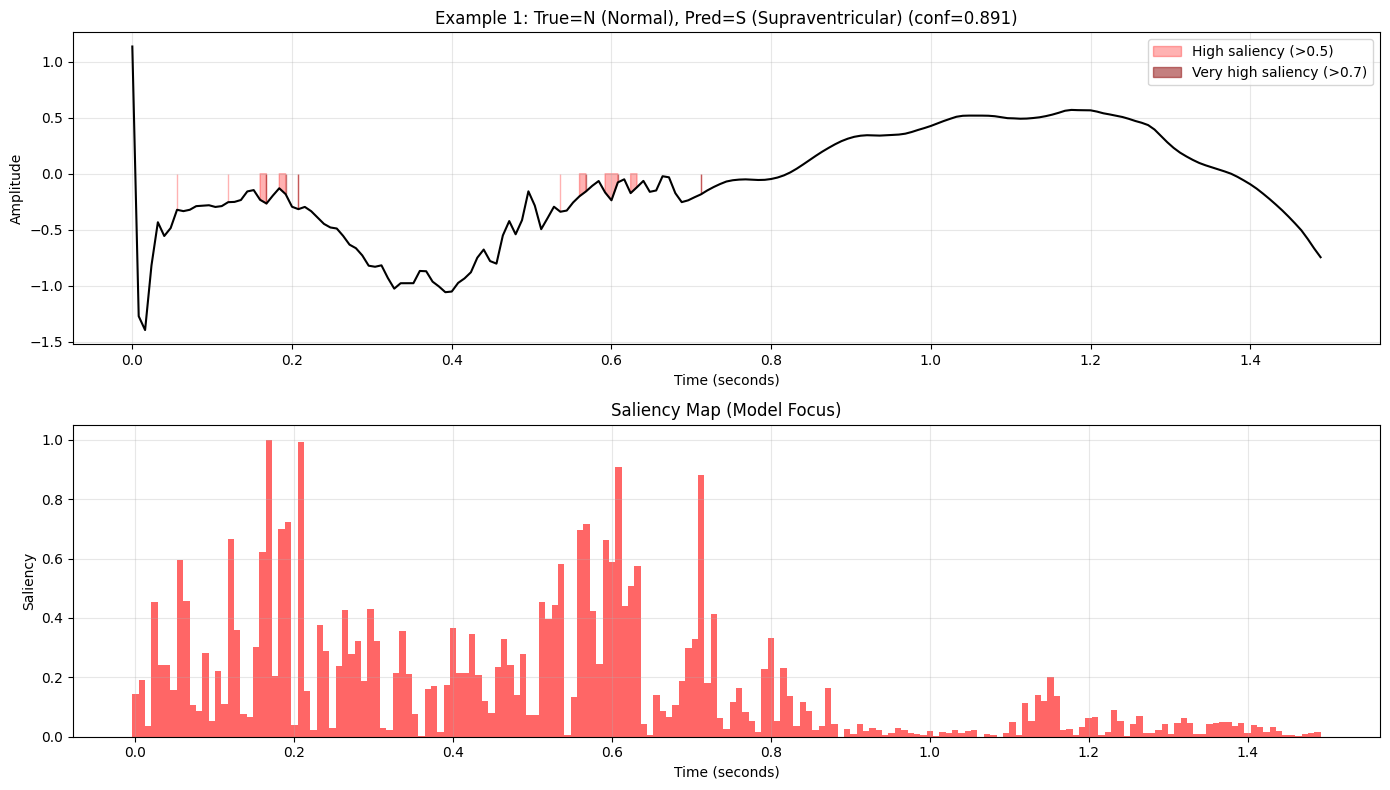

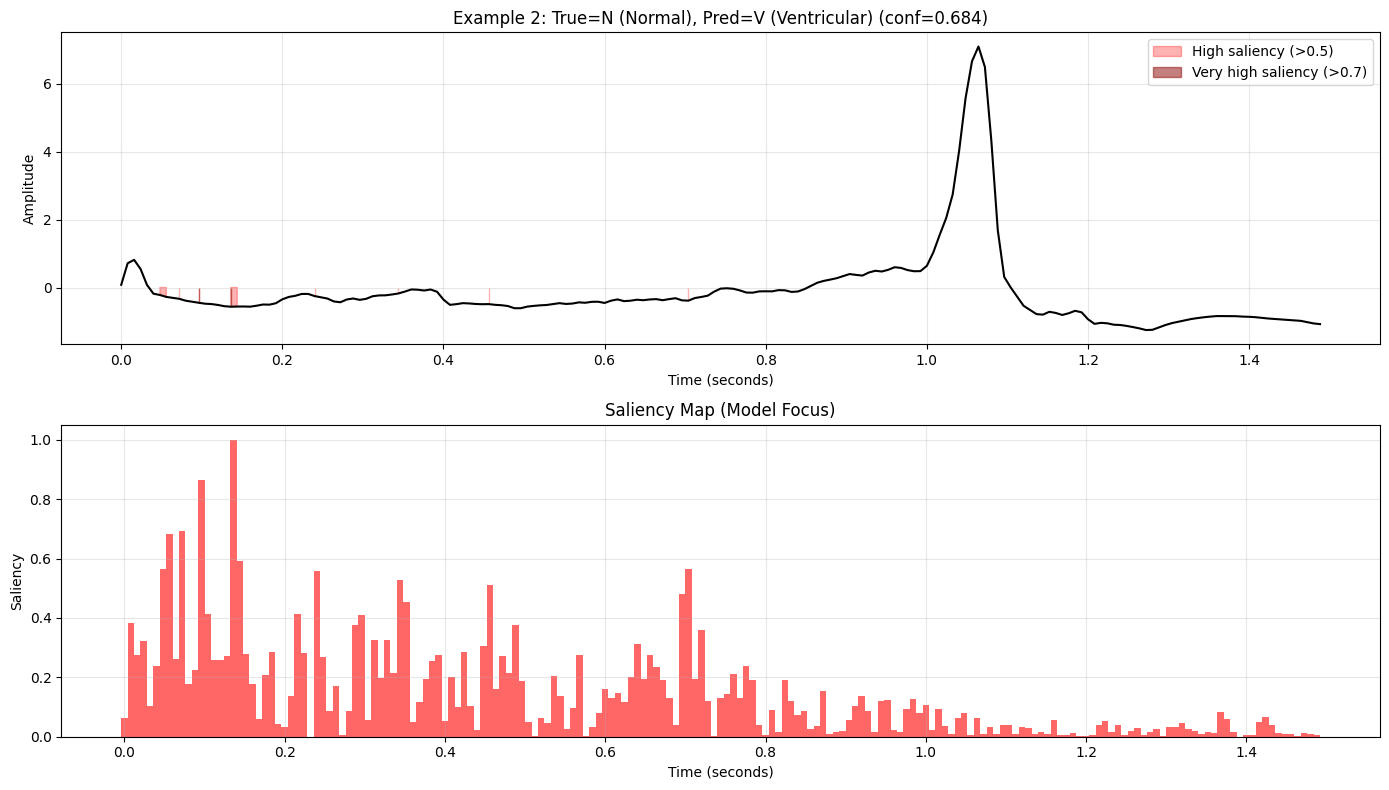

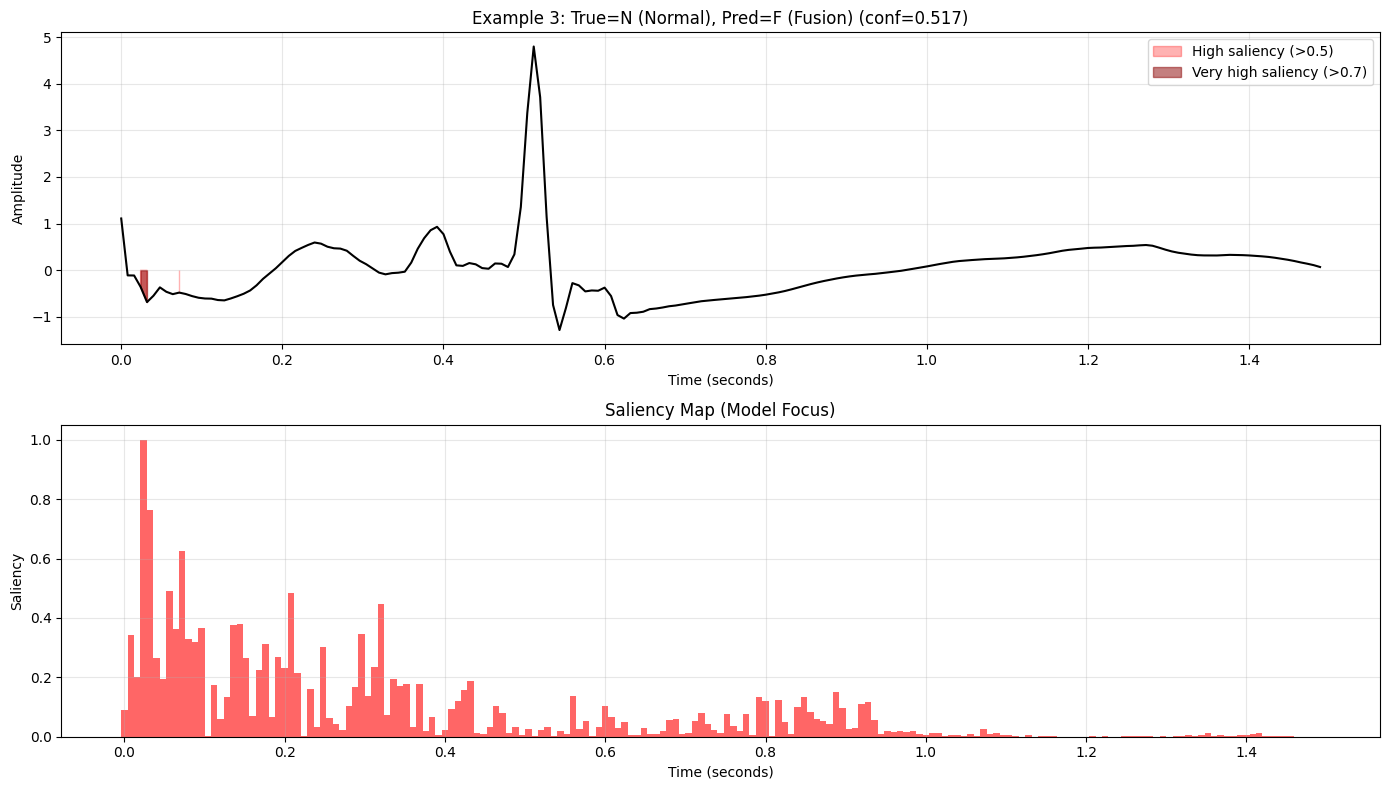

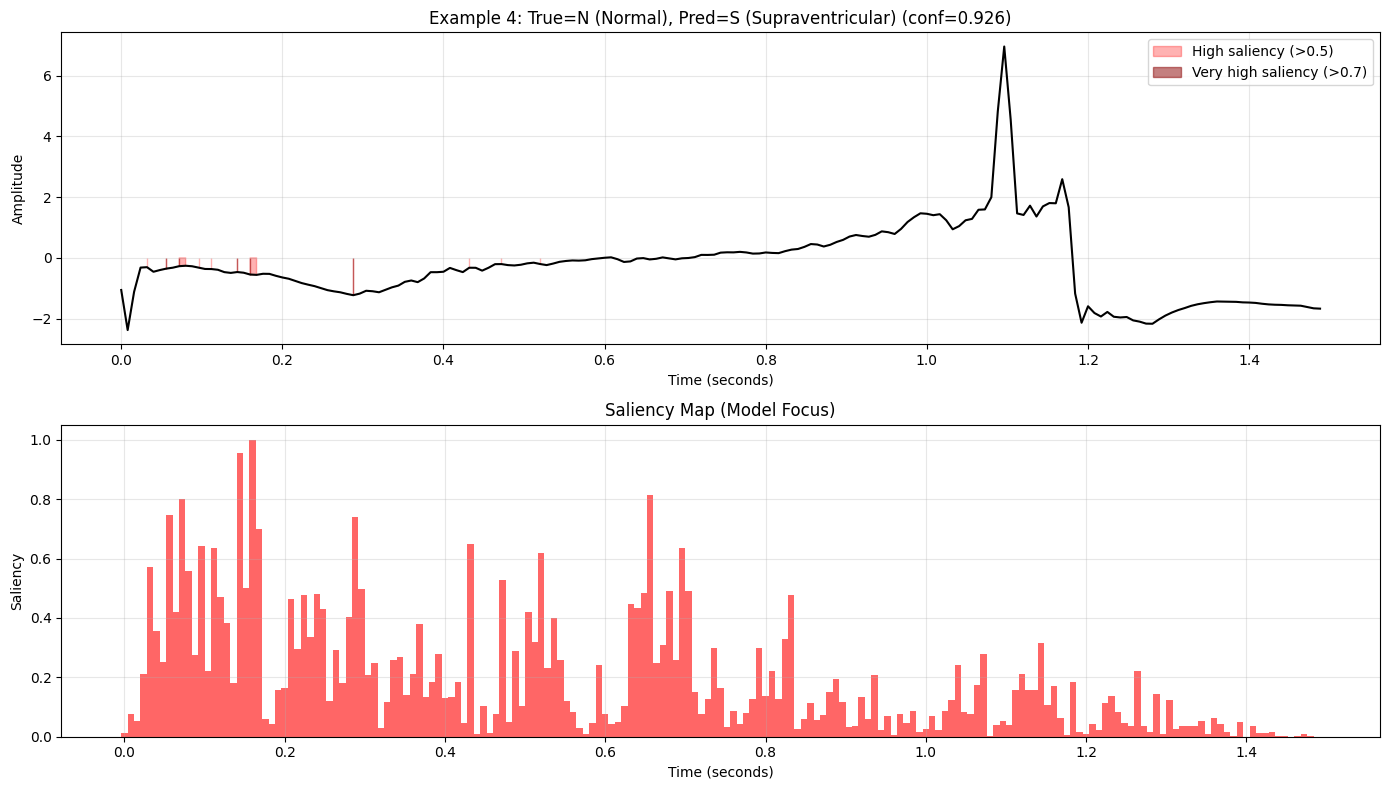

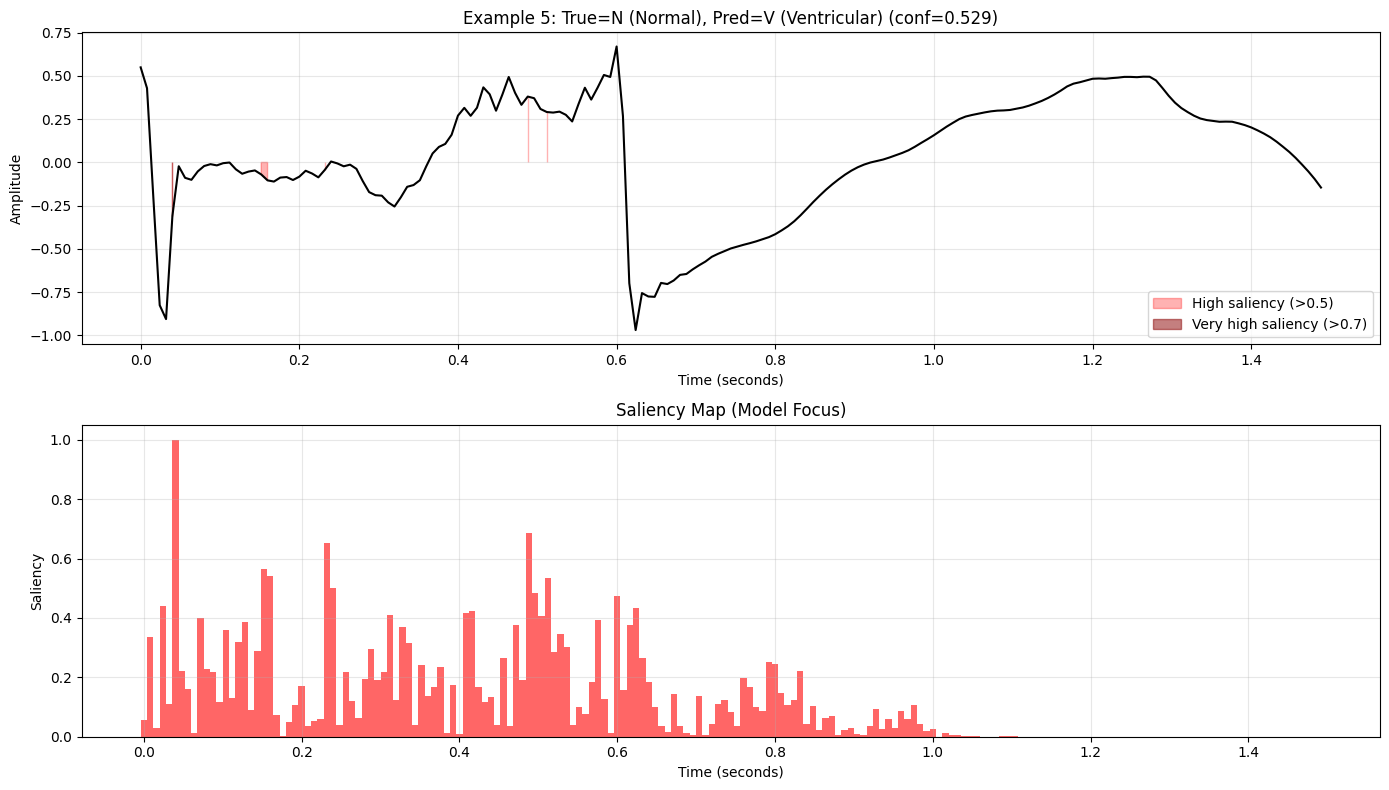


✅ Model metadata saved to 'model_metadata.json'

TRAINING COMPLETE


In [ ]:
"""
ECG Arrhythmia Classification Training Script
With Interpretability (Saliency Maps) and Calibration Analysis
Dataset: MIT-BIH from Kaggle (125 Hz, 187 samples per heartbeat + 1 label)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score #roc/prc
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from imblearn.combine import SMOTETomek
import tensorflow as tf
# from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import backend as K
# from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Flatten, Dense, Dropout, BatchNormalization,
    Concatenate, Activation, Add
)
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# DATASET-SPECIFIC CONSTANTS - CORRECTED
# =============================================================================
TARGET_FS = 125           # Sampling frequency from dataset
TARGET_LENGTH = 187       # Actual number of samples per heartbeat (from CSV shape)
N_CLASSES = 5             # Number of arrhythmia classes
CLASS_NAMES = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)',
               'F (Fusion)', 'Q (Unknown)']
CLASS_COLORS = ['#28a745', '#fd7e14', '#dc3545', '#6f42c1', '#17a2b8']

# =============================================================================
# Custom Metrics
# =============================================================================
def sensitivity(y_true, y_pred):
    """Sensitivity (Recall) metric"""
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + K.epsilon())

def specificity(y_true, y_pred):
    """Specificity metric"""
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    true_negatives = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1 - y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

def f1_score(y_true, y_pred):
    """F1 Score metric"""
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))

    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())

    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

# =============================================================================
# Feature Extraction
# =============================================================================
def extract_handcrafted_features(X):
    """Extract 6 handcrafted features from ECG signals"""
    features = []

    for sample in X:
        sample_flat = sample.flatten()

        # Statistical features
        mean_val = np.mean(sample_flat)
        std_val = np.std(sample_flat)
        skewness_val = skew(sample_flat)
        kurtosis_val = kurtosis(sample_flat)

        # Morphological features (adjusted for 125 Hz)
        min_distance = int(0.4 * TARGET_FS)  # Minimum 400ms between peaks
        peak_height = np.percentile(sample_flat, 75)

        peaks, _ = signal.find_peaks(
            sample_flat,
            height=peak_height,
            distance=min_distance
        )
        num_peaks = len(peaks)

        # Energy features
        energy = np.sum(sample_flat ** 2)

        features.append([mean_val, std_val, skewness_val, kurtosis_val,
                         num_peaks, energy])

    return np.array(features)

# =============================================================================
# Data Loading and Preprocessing - CORRECTED
# =============================================================================
def load_and_preprocess():
    print("="*50)
    print("Loading MIT-BIH dataset from Kaggle")
    print(f"Sampling frequency: {TARGET_FS} Hz")
    print(f"Heartbeat length: {TARGET_LENGTH} samples (from CSV)")
    print("="*50)

    # Load data
    df_train = pd.read_csv('data/mitbih_train.csv', header=None)
    df_test = pd.read_csv('data/mitbih_test.csv', header=None)

    # Verify shapes
    print(f"\nTrain CSV shape: {df_train.shape} (should be 87554 rows × 187 columns)")
    print(f"Test CSV shape: {df_test.shape} (should be 21892 rows × 187 columns)")

    # Extract features (first 187 columns) and labels (last column)
    X_train = df_train.iloc[:, :-1].values.astype(np.float32)  # Shape: (87554, 187)
    y_train = df_train.iloc[:, -1].values.astype(np.int32)
    X_test = df_test.iloc[:, :-1].values.astype(np.float32)    # Shape: (21892, 187)
    y_test = df_test.iloc[:, -1].values.astype(np.int32)

    print(f"\nExtracted shapes:")
    print(f"X_train: {X_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"Train class distribution: {np.bincount(y_train)}")
    print(f"Test class distribution: {np.bincount(y_test)}")

    # Apply bandpass filter (0.5-45 Hz) for 125 Hz
    nyquist = 0.5 * TARGET_FS
    low = 0.5 / nyquist
    high = 45.0 / nyquist

    print(f"\nBandpass filter parameters (0.5-45 Hz):")
    print(f"Nyquist: {nyquist} Hz")
    print(f"Low cutoff normalized: {low:.4f}")
    print(f"High cutoff normalized: {high:.4f}")

    b, a = signal.butter(4, [low, high], btype='band')

    print("Applying bandpass filter...")
    X_train_filtered = signal.filtfilt(b, a, X_train, axis=1)
    X_test_filtered = signal.filtfilt(b, a, X_test, axis=1)

    # Extract handcrafted features
    print("\nExtracting handcrafted features...")
    train_features = extract_handcrafted_features(X_train_filtered)
    test_features = extract_handcrafted_features(X_test_filtered)
    print(f"Train features shape: {train_features.shape}")
    print(f"Test features shape: {test_features.shape}")

    # Normalize signals
    print("\nNormalizing signals...")
    signal_scaler = StandardScaler()
    X_train_norm = signal_scaler.fit_transform(X_train_filtered)
    X_test_norm = signal_scaler.transform(X_test_filtered)

    # Verify normalization
    print(f"X_train_norm shape: {X_train_norm.shape}")
    print(f"X_train_norm mean: {np.mean(X_train_norm):.6f}")
    print(f"X_train_norm std: {np.std(X_train_norm):.6f}")

    # Normalize features
    print("\nNormalizing features...")
    feature_scaler = StandardScaler()
    train_features = feature_scaler.fit_transform(train_features)
    test_features = feature_scaler.transform(test_features)

    print(f"Train features normalized shape: {train_features.shape}")
    print(f"Test features normalized shape: {test_features.shape}")

    # Reshape for CNN - USING CORRECT TARGET_LENGTH (187)
    X_train = X_train_norm.reshape(-1, TARGET_LENGTH, 1)
    X_test = X_test_norm.reshape(-1, TARGET_LENGTH, 1)

    # Convert labels
    y_train_cat = to_categorical(y_train, N_CLASSES)
    y_test_cat = to_categorical(y_test, N_CLASSES)

    print(f"\nFinal shapes:")
    print(f"X_train: {X_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"y_train_cat: {y_train_cat.shape}")
    print(f"y_test_cat: {y_test_cat.shape}")
    print(f"train_features: {train_features.shape}")
    print(f"test_features: {test_features.shape}")

    # Verify total samples
    total_train_samples = X_train.shape[0] * TARGET_LENGTH
    print(f"\nVerification: Total train samples = {total_train_samples}")
    print(f"Original train samples = {X_train_filtered.size}")
    assert total_train_samples == X_train_filtered.size, "Reshape error!"

    return (X_train, y_train, y_train_cat, train_features,
            X_test, y_test, y_test_cat, test_features,
            signal_scaler, feature_scaler)

# =============================================================================
# Model Architecture - UPDATED INPUT SHAPE
# =============================================================================
def residual_block(x, filters, kernel_size=5, dropout_rate=0.3):
    """Residual block with batch normalization"""
    from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Dropout, Add
    from tensorflow.keras.regularizers import l2

    shortcut = x

    # First convolution
    x = Conv1D(filters, kernel_size, padding='same',
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    # Second convolution
    x = Conv1D(filters, kernel_size, padding='same',
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)

    # Add shortcut if dimensions match
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

def build_model():
    """Build dual-input model for 125 Hz, 187-sample ECG"""
    from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Flatten, Dense, Dropout, BatchNormalization, Concatenate
    from tensorflow.keras.models import Model
    from tensorflow.keras.regularizers import l2

    print("\n" + "="*50)
    print("Building model for 125 Hz ECG signals")
    print(f"Input shape: ({TARGET_LENGTH}, 1)")
    print("="*50)

    # Signal input branch
    signal_input = Input(shape=(TARGET_LENGTH, 1), name='signal_input')

    # Initial convolution
    x = Conv1D(32, 15, padding='same', kernel_regularizer=l2(1e-4))(signal_input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2)(x)  # 187 -> 93 (floor division)

    # Residual blocks
    x = residual_block(x, 64, kernel_size=11, dropout_rate=0.2)
    x = MaxPooling1D(2)(x)  # 93 -> 46

    x = residual_block(x, 128, kernel_size=7, dropout_rate=0.3)
    x = MaxPooling1D(2)(x)  # 46 -> 23

    x = residual_block(x, 256, kernel_size=5, dropout_rate=0.4)
    # Final shape: (None, 23, 256)

    # Multi-scale feature extraction
    pool1 = GlobalAveragePooling1D()(x)  # (None, 256)
    pool2 = MaxPooling1D(pool_size=2)(x)  # (None, 11, 256)
    pool2 = Flatten()(pool2)  # (None, 2816)

    signal_features = Concatenate()([pool1, pool2])  # (None, 3072)

    # Feature input branch
    feature_input = Input(shape=(6,), name='feature_input')
    f = Dense(32, activation='relu', kernel_regularizer=l2(1e-4))(feature_input)
    f = BatchNormalization()(f)
    f = Dropout(0.3)(f)

    # Combine branches
    combined = Concatenate()([signal_features, f])  # (None, 3104)

    # Dense layers
    z = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(combined)
    z = BatchNormalization()(z)
    z = Dropout(0.5)(z)

    z = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(z)
    z = BatchNormalization()(z)
    z = Dropout(0.4)(z)

    # Output layer
    output = Dense(N_CLASSES, activation='softmax', name='output')(z)

    # Create model
    model = Model(inputs=[signal_input, feature_input], outputs=output)

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy', sensitivity, specificity, f1_score]
    )

    model.summary()
    return model

# =============================================================================
# Data Augmentation
# =============================================================================
def add_noise_augmentation(X, y, noise_factor=0.02, num_augmented=None):
    """Add Gaussian noise for data augmentation"""
    if num_augmented is None:
        num_augmented = len(X) // 3

    indices = np.random.choice(len(X), num_augmented, replace=False)
    X_noisy = X[indices].copy()

    # Adjust noise for 125 Hz
    noise = np.random.normal(0, noise_factor * 1.2, X_noisy.shape)
    X_noisy += noise

    return np.vstack([X, X_noisy]), np.hstack([y, y[indices]])

# =============================================================================
# INTERPRETABILITY FUNCTIONS
# =============================================================================

def generate_saliency_map(model, X_sample, feature_sample, class_idx):
    """
    Generate saliency map for a specific sample and class using gradient information.
    """
    # Convert to tensors
    X_tensor = tf.convert_to_tensor(X_sample.reshape(1, TARGET_LENGTH, 1), dtype=tf.float32)
    feature_tensor = tf.convert_to_tensor(feature_sample.reshape(1, 6), dtype=tf.float32)

    # Watch the input tensor
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        # Get predictions
        predictions = model([X_tensor, feature_tensor])
        # Get score for target class
        class_score = predictions[:, class_idx]

    # Compute gradients
    gradients = tape.gradient(class_score, X_tensor)

    # Convert to numpy and take absolute values
    saliency = np.abs(gradients.numpy().squeeze())

    # Normalize for visualization
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    return saliency

def plot_saliency_map(ecg_signal, saliency_map, class_name, confidence, save_path=None):
    """Plot ECG signal with overlaid saliency map."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
                                    gridspec_kw={'height_ratios': [3, 1]})

    # Time axis
    time = np.arange(len(ecg_signal)) / TARGET_FS

    # Plot ECG with saliency heatmap
    ax1.plot(time, ecg_signal, color='black', linewidth=1, alpha=0.7)

    # Create color-coded saliency overlay
    scatter = ax1.scatter(time, ecg_signal, c=saliency_map,
                          cmap='hot', s=10, alpha=0.6)

    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Amplitude')
    ax1.set_title(f'ECG with Saliency Map - Predicted: {class_name} (Confidence: {confidence:.3f})')
    ax1.grid(True, alpha=0.3)

    # Colorbar
    plt.colorbar(scatter, ax=ax1, label='Saliency')

    # Plot saliency alone
    ax2.fill_between(time, saliency_map, alpha=0.5, color='red')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Saliency')
    ax2.set_title('Saliency Map (Regions most important for classification)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    return fig

# =============================================================================
# CALIBRATION FUNCTIONS
# =============================================================================

def calculate_ece(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error (ECE) for multi-class classification."""
    ece = 0
    n_classes = y_true.shape[1]

    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(
            y_true[:, i], y_prob[:, i],
            n_bins=n_bins, strategy='uniform'
        )

        # Get bin counts
        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_indices = np.digitize(y_prob[:, i], bin_edges[1:-1])

        # Calculate bin weights
        bin_counts = np.bincount(bin_indices, minlength=n_bins)
        bin_weights = bin_counts / len(y_prob)

        # Calculate ECE for this class
        for bin_idx in range(len(prob_true)):
            if bin_counts[bin_idx] > 0:
                ece += bin_weights[bin_idx] * np.abs(prob_true[bin_idx] - prob_pred[bin_idx])

    # Average over classes
    ece = ece / n_classes

    return ece

def plot_calibration_curves(y_true, y_prob, class_names, save_path=None):
    """Plot calibration curves for all classes."""
    n_classes = y_true.shape[1]

    plt.figure(figsize=(14, 8))

    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(
            y_true[:, i], y_prob[:, i],
            n_bins=10, strategy='uniform'
        )

        plt.plot(prob_pred, prob_true, marker='o',
                linewidth=2, label=f'{class_names[i]}',
                color=CLASS_COLORS[i])

    # Perfect calibration line
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray',
             linewidth=2, label='Perfectly Calibrated')

    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title('Calibration Curves (Reliability Diagrams)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def calculate_brier_scores(y_true, y_prob):
    """Calculate Brier scores for each class and overall."""
    n_classes = y_true.shape[1]
    brier_per_class = []

    for i in range(n_classes):
        brier = brier_score_loss(y_true[:, i], y_prob[:, i])
        brier_per_class.append(brier)

    # Overall Brier score (average across classes)
    brier_overall = np.mean(brier_per_class)

    return {
        'per_class': brier_per_class,
        'overall': brier_overall
    }

def plot_confidence_histogram(y_prob, class_names, save_path=None):
    """Plot histogram of confidence scores."""
    n_classes = y_prob.shape[1]
    confidence_scores = np.max(y_prob, axis=1)
    predicted_classes = np.argmax(y_prob, axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Overall confidence histogram
    axes[0].hist(confidence_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.7)
    axes[0].axvline(np.mean(confidence_scores), color='red', linestyle='--',
                    label=f'Mean: {np.mean(confidence_scores):.3f}')
    axes[0].set_xlabel('Confidence Score')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Confidence Scores')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Confidence by class
    for i in range(n_classes):
        class_confidences = confidence_scores[predicted_classes == i]
        if len(class_confidences) > 0:
            axes[1].hist(class_confidences, bins=15, alpha=0.6,
                        color=CLASS_COLORS[i], label=class_names[i])

    axes[1].set_xlabel('Confidence Score')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Confidence Scores by Predicted Class')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def calibration_report(y_true, y_prob, class_names):
    """Generate comprehensive calibration report."""
    print("\n" + "="*60)
    print("CALIBRATION ANALYSIS REPORT")
    print("="*60)

    # Calculate ECE
    ece = calculate_ece(y_true, y_prob)
    print(f"\n📊 Expected Calibration Error (ECE): {ece:.6f}")
    print(f"   → {'Well calibrated' if ece < 0.05 else 'Moderately calibrated' if ece < 0.1 else 'Poorly calibrated'}")

    # Calculate Brier scores
    brier_scores = calculate_brier_scores(y_true, y_prob)
    print(f"\n📈 Brier Scores (lower is better, range 0-1):")
    print(f"   → Overall Brier Score: {brier_scores['overall']:.6f}")

    for i, brier in enumerate(brier_scores['per_class']):
        print(f"   → {class_names[i]}: {brier:.6f}")

    # Confidence statistics
    confidence_scores = np.max(y_prob, axis=1)
    predicted_classes = np.argmax(y_prob, axis=1)

    print(f"\n🔍 Confidence Statistics:")
    print(f"   → Mean confidence: {np.mean(confidence_scores):.4f}")
    print(f"   → Median confidence: {np.median(confidence_scores):.4f}")
    print(f"   → Std confidence: {np.std(confidence_scores):.4f}")
    print(f"   → % High confidence (>0.9): {np.mean(confidence_scores > 0.9)*100:.2f}%")

    # Confidence by class
    print(f"\n📊 Confidence by Predicted Class:")
    for i in range(len(class_names)):
        class_conf = confidence_scores[predicted_classes == i]
        if len(class_conf) > 0:
            print(f"   → {class_names[i]}: mean={np.mean(class_conf):.4f}, "
                  f"median={np.median(class_conf):.4f}, n={len(class_conf)}")

    return {
        'ece': ece,
        'brier_overall': brier_scores['overall'],
        'brier_per_class': brier_scores['per_class'],
        'mean_confidence': np.mean(confidence_scores),
        'high_confidence_rate': np.mean(confidence_scores > 0.9)
    }

def analyze_misclassifications_with_saliency(model, X_test, features_test, y_test, y_pred,
                                             class_names, num_examples=5, save_dir='misclassifications'):
    """Analyze misclassified samples with saliency maps."""
    import os
    os.makedirs(save_dir, exist_ok=True)

    # Find misclassified indices
    y_true_class = np.argmax(y_test, axis=1)
    y_pred_class = np.argmax(y_pred, axis=1)
    misclassified = np.where(y_true_class != y_pred_class)[0]

    print(f"\n{'='*60}")
    print(f"MISCLASSIFICATION ANALYSIS WITH SALIENCY MAPS")
    print(f"{'='*60}")
    print(f"Total misclassified samples: {len(misclassified)}")

    # Analyze by confusion pair
    confusion_pairs = {}
    for idx in misclassified[:min(100, len(misclassified))]:
        true = y_true_class[idx]
        pred = y_pred_class[idx]
        pair = f"{class_names[true]} → {class_names[pred]}"
        confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

    print("\nMost common confusion patterns:")
    for pair, count in sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {pair}: {count} samples")

    # Generate saliency maps for examples
    print(f"\nGenerating saliency maps for {num_examples} examples...")

    for i, idx in enumerate(misclassified[:num_examples]):
        X_sample = X_test[idx]
        feature_sample = features_test[idx]
        true_class = y_true_class[idx]
        pred_class = y_pred_class[idx]
        confidence = np.max(y_pred[idx])

        # Generate saliency map
        saliency = generate_saliency_map(model, X_sample, feature_sample, pred_class)

        # Plot
        fig, axes = plt.subplots(2, 1, figsize=(14, 8))

        # Time axis
        time = np.arange(TARGET_LENGTH) / TARGET_FS

        # Plot ECG with saliency
        axes[0].plot(time, X_sample.flatten(), color='black', linewidth=1.5)
        axes[0].fill_between(time, X_sample.flatten(),
                             where=(saliency > 0.5),
                             alpha=0.3, color='red', label='High saliency (>0.5)')
        axes[0].fill_between(time, X_sample.flatten(),
                             where=(saliency > 0.7),
                             alpha=0.5, color='darkred', label='Very high saliency (>0.7)')
        axes[0].set_title(f'Example {i+1}: True={class_names[true_class]}, Pred={class_names[pred_class]} (conf={confidence:.3f})')
        axes[0].set_xlabel('Time (seconds)')
        axes[0].set_ylabel('Amplitude')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Plot saliency
        axes[1].bar(time, saliency, width=1/TARGET_FS, color='red', alpha=0.6)
        axes[1].set_xlabel('Time (seconds)')
        axes[1].set_ylabel('Saliency')
        axes[1].set_title('Saliency Map (Model Focus)')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'{save_dir}/misclassification_{i+1}_true{true_class}_pred{pred_class}.png',
                   dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

# =============================================================================
# Main Training Function
# =============================================================================
def main():
    print("TensorFlow version:", tf.__version__)
    print("GPU Available:", tf.config.list_physical_devices('GPU'))

    # Load and preprocess data
    (X_train, y_train_int, y_train, X_train_features,
     X_test, y_test_int, y_test, X_test_features,
     signal_scaler, feature_scaler) = load_and_preprocess()

    # Save scalers for later use in deployment
    joblib.dump(signal_scaler, 'signal_scaler.pkl')
    joblib.dump(feature_scaler, 'feature_scaler.pkl')
    print("\n✅ Scalers saved for deployment")

    # Data balancing
    print("\n" + "="*50)
    print("Applying SMOTE-Tomek for class balancing")
    print("="*50)

    X_flat = X_train.reshape(X_train.shape[0], -1)

    smote_tomek = SMOTETomek(random_state=42)
    X_res_flat, y_res = smote_tomek.fit_resample(X_flat, y_train_int)

    print(f"Before SMOTE: {len(X_train)} samples")
    print(f"After SMOTE: {len(X_res_flat)} samples")
    print(f"Class distribution after SMOTE: {np.bincount(y_res)}")

    # Add noise augmentation
    X_res_flat, y_res = add_noise_augmentation(X_res_flat, y_res, noise_factor=0.02)

    # Reshape back
    X_res = X_res_flat.reshape(-1, TARGET_LENGTH, 1)
    y_res_cat = to_categorical(y_res, N_CLASSES)

    # Augment features (simplified approach)
    X_res_features = np.zeros((len(X_res), X_train_features.shape[1]))
    for i in range(len(X_res)):
        idx = i % len(X_train_features)
        X_res_features[i] = X_train_features[idx]

    print(f"\nFinal training data shape: {X_res.shape}")
    print(f"Final features shape: {X_res_features.shape}")

    # Train/validation split
    print("\n" + "="*50)
    print("Splitting data for training and validation")
    print("="*50)

    X_train_split, X_val_split, X_train_feat_split, X_val_feat_split, y_train_split, y_val_split = train_test_split(
        X_res, X_res_features, y_res_cat, test_size=0.2, random_state=42, stratify=y_res
    )

    print(f"Training samples: {len(X_train_split)}")
    print(f"Validation samples: {len(X_val_split)}")

    # Build model
    model = build_model()

    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_f1_score',
            mode='max',
            patience=20,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=8,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            'best_model_125Hz.h5',
            monitor='val_f1_score',
            mode='max',
            save_best_only=True,
            verbose=1
        )
    ]

    # Train model
    print("\n" + "="*50)
    print("Starting training...")
    print("="*50)

    history = model.fit(
        [X_train_split, X_train_feat_split],
        y_train_split,
        epochs=100,
        batch_size=64,
        validation_data=([X_val_split, X_val_feat_split], y_val_split),
        callbacks=callbacks,
        shuffle=True,
        verbose=1
    )

    # Save final model
    model.save('ecg_model_final_125Hz.h5')
    print("\n✅ Model saved as 'ecg_model_final_125Hz.h5'")

    # =============================================================================
    # EVALUATION ON TEST SET
    # =============================================================================
    print("\n" + "="*60)
    print("EVALUATION ON TEST SET")
    print("="*60)

    loss, accuracy, sens, spec, f1 = model.evaluate(
        [X_test, X_test_features], y_test, verbose=0
    )

    print(f"\nTest Results:")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity: {sens:.4f}")
    print(f"Specificity: {spec:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Get predictions
    y_pred = model.predict([X_test, X_test_features], batch_size=256, verbose=0)
    y_pred_class = np.argmax(y_pred, axis=1)
    y_true_class = np.argmax(y_test, axis=1)


    #####
    # Classification report
    print("\nDetailed Classification Report:")
    print(classification_report(y_true_class, y_pred_class,
                              target_names=['N', 'S', 'V', 'F', 'Q'],
                              digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true_class, y_pred_class)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['N', 'S', 'V', 'F', 'Q'],
                yticklabels=['N', 'S', 'V', 'F', 'Q'])
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)
    plt.title('Test Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ROC AUC for each class
    try:
        y_pred_proba = y_pred  # Already probabilities
        roc_auc = roc_auc_score(y_test, y_pred_proba, average='weighted', multi_class='ovr')
        print(f"Weighted ROC-AUC: {roc_auc:.4f}")
    except Exception as e:
        print(f"Could not compute ROC-AUC: {e}")

    # Per-class metrics
    print("\nPer-Class Performance:")
    for i, class_name in enumerate(['N', 'S', 'V', 'F', 'Q']):
        class_pred = (y_pred_class == i).astype(int)
        class_true = (y_true_class == i).astype(int)
        accuracy = np.mean(class_pred == class_true)
        print(f"{class_name}: Accuracy = {accuracy:.4f}")

    # Plot training history
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # F1 Score
    if 'f1_score' in history.history:
        axes[1, 0].plot(history.history['f1_score'], label='Train', linewidth=2)
        axes[1, 0].plot(history.history['val_f1_score'], label='Validation', linewidth=2)
        axes[1, 0].set_title('F1 Score', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('F1 Score')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

    # Learning Rate
    if 'lr' in history.history:
        axes[1, 1].plot(history.history['lr'], linewidth=2)
        axes[1, 1].set_title('Learning Rate', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    #---------------------
    # ROC/PRC
    #---------------------
    n_classes = y_test.shape[1] # Number of classes

    # ────────────────────────────────────────────────
    # Plotting ROC Curves
    # ────────────────────────────────────────────────

    plt.figure(figsize=(12, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    # ────────────────────────────────────────────────
    # Plotting Precision-Recall Curves
    # ────────────────────────────────────────────────

    plt.figure(figsize=(12, 8))
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test[:, i], y_pred[:, i])
        ap_score = average_precision_score(y_test[:, i], y_pred[:, i])
        plt.plot(recall, precision, label=f'Class {i} (AP = {ap_score:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()


    # ────────────────────────────────────────────────
    # Error Analysis
    # ────────────────────────────────────────────────

    # Find misclassified samples
    misclassified_indices = np.where(y_pred_class != y_true_class)[0]

    if len(misclassified_indices) > 0:
        print(f"\nTotal misclassified samples: {len(misclassified_indices)}")

        # Show some example misclassifications
        num_examples = min(5, len(misclassified_indices))
        fig, axes = plt.subplots(1, num_examples, figsize=(15, 3))

        if num_examples == 1:
            axes = [axes]

        for i, idx in enumerate(misclassified_indices[:num_examples]):
            axes[i].plot(X_test[idx].flatten())
            axes[i].set_title(f'True: {y_true_class[idx]}, Pred: {y_pred_class[idx]}')
            axes[i].set_xlabel('Sample')
            axes[i].set_ylabel('Amplitude')

        plt.suptitle('Misclassified ECG Samples', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()


    #####



    # =============================================================================
    # CALIBRATION ANALYSIS
    # =============================================================================
    print("\n" + "="*60)
    print("CALIBRATION ANALYSIS")
    print("="*60)

    # Generate calibration report
    cal_metrics = calibration_report(y_test, y_pred, CLASS_NAMES)

    # Plot calibration curves
    plot_calibration_curves(y_test, y_pred, CLASS_NAMES,
                           save_path='calibration_curves.png')

    # Plot confidence histogram
    plot_confidence_histogram(y_pred, CLASS_NAMES,
                            save_path='confidence_histogram.png')

    # =============================================================================
    # INTERPRETABILITY ANALYSIS
    # =============================================================================
    print("\n" + "="*60)
    print("INTERPRETABILITY ANALYSIS")
    print("="*60)

    # Generate saliency maps for correctly classified examples
    print("\nGenerating saliency maps for correctly classified examples...")
    correct_indices = np.where(y_pred_class == y_true_class)[0]

    # Select one example per class
    for class_idx in range(N_CLASSES):
        class_correct = correct_indices[y_true_class[correct_indices] == class_idx]
        if len(class_correct) > 0:
            sample_idx = class_correct[0]
            X_sample = X_test[sample_idx]
            feature_sample = X_test_features[sample_idx]
            confidence = np.max(y_pred[sample_idx])

            # Generate saliency map
            saliency = generate_saliency_map(model, X_sample, feature_sample, class_idx)

            # Plot
            plot_saliency_map(
                X_sample.flatten(), saliency,
                CLASS_NAMES[class_idx], confidence,
                save_path=f'saliency_class_{class_idx}.png'
            )

    # Analyze misclassifications with saliency
    analyze_misclassifications_with_saliency(
        model, X_test, X_test_features, y_test, y_pred,
        CLASS_NAMES, num_examples=5
    )

    # =============================================================================
    # SAVE ADDITIONAL METADATA FOR DEPLOYMENT
    # =============================================================================
    metadata = {
        'target_fs': TARGET_FS,
        'target_length': TARGET_LENGTH,
        'n_classes': N_CLASSES,
        'class_names': CLASS_NAMES,
        'test_accuracy': float(accuracy),
        'test_f1': float(f1),
        'test_sensitivity': float(sens),
        'test_specificity': float(spec),
        'ece': float(cal_metrics['ece']),
        'brier_score': float(cal_metrics['brier_overall'])
    }

    with open('model_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=4)

    print("\n✅ Model metadata saved to 'model_metadata.json'")
    print("\n" + "="*60)
    print("TRAINING COMPLETE")
    print("="*60)

    return model, history, cal_metrics

if __name__ == "__main__":
    model, history, cal_metrics = main()

In [5]:
# After training, save history
import json
history_dict = {key: [float(val) for val in values]
                for key, values in history.history.items()}
with open('training_history.json', 'w') as f:
    json.dump(history_dict, f)

In [1]:
import wfdb
import pandas as pd

# 1. Download and read the record (212) from PhysioNet
# This will fetch the .hea and .dat files automatically
record = wfdb.rdrecord('111', pn_dir='mitdb')

# 2. Convert the signal to a Pandas DataFrame
df = pd.DataFrame(record.p_signal, columns=record.sig_name)

# 3. Add a time column (optional but helpful)
# Sampling frequency (fs) for mitdb is 360Hz
df.insert(0, 'Time_s', [i/record.fs for i in range(len(df))])
df2 = df[['MLII']]

# 4. Save to CSV
df2.to_csv('mitdb_111_complete.csv', index=False)
print("Record saved as csv with single lead")

Record saved as csv with single lead


In [10]:
import wfdb
import pandas as pd

def save_record_as_csv(record_name, output_file, duration_seconds=30):
    """Save MIT-BIH record as CSV for app testing"""
    record = wfdb.rdrecord(record_name, pn_dir='mitdb', 
                           sampto=duration_seconds * 360)  # 360 Hz
    ecg_signal = record.p_signal[:, 0]  # MLII lead
    df = pd.DataFrame({'ecg_signal': ecg_signal})
    df.to_csv(output_file, index=False)
    print(f"Saved {record_name} to {output_file}")

# Save recommended records
save_record_as_csv('119', 'test_ventricular30s_mita119.csv', duration_seconds=30)
save_record_as_csv('228', 'test_mixed30s_mita228.csv', duration_seconds=30)
save_record_as_csv('232', 'test_supraventricular30s_mita232.csv', duration_seconds=30)

Saved 119 to test_ventricular30s_mita119.csv
Saved 228 to test_mixed30s_mita228.csv
Saved 232 to test_supraventricular30s_mita232.csv


In [ ]:
import wfdb
import pandas as pd

# 1. Download and read the record (212) from PhysioNet
# This will fetch the .hea and .dat files automatically
record = wfdb.rdrecord('111', pn_dir='mitdb')

# 2. Convert the signal to a Pandas DataFrame
df = pd.DataFrame(record.p_signal, columns=record.sig_name)

# 3. Add a time column (optional but helpful)
# Sampling frequency (fs) for mitdb is 360Hz
df.insert(0, 'Time_s', [i/record.fs for i in range(len(df))])
df2 = df[['MLII']]

The **Expected Calibration Error (ECE)** is a metric used to evaluate how well-calibrated a machine learning model's predicted probabilities are.

Let's break down what **ECE: 0.1438** means:

1.  **What is Calibration?**
    A model is considered well-calibrated if its predicted probabilities reflect the true likelihood of an event occurring.
    *   If a model predicts an 80% chance for 100 different instances, then ideally, approximately 80 of those instances should actually belong to the predicted class.
    *   If a model predicts a 50% chance for 100 instances, then roughly 50 of them should be correct.

2.  **How ECE is Calculated (Simplified):**
    ECE works by dividing the model's predictions into several confidence "bins" (e.g., 0-10%, 10-20%, ..., 90-100%). For each bin, it calculates:
    *   The **average confidence** of predictions falling into that bin.
    *   The **actual accuracy** (proportion of correct predictions) for samples in that bin.
    It then takes a weighted average of the absolute differences between the average confidence and the accuracy across all bins.

3.  **Meaning of the Value 0.1438:**
    *   **Range:** ECE typically ranges from 0 to 1.
    *   **0 (Zero):** A perfect ECE of 0 would mean the model is perfectly calibrated. Its predicted probabilities exactly match the true probabilities across all confidence levels.
    *   **Higher Values:** Higher ECE values indicate poorer calibration. The model's confidence in its predictions does not accurately reflect how often it is actually correct.

    Therefore, an ECE of **0.1438** means that, on average, there is a **14.38 percentage point difference** between the model's predicted confidence and its actual accuracy.

    **Example:**
    *   If the model frequently predicts 80% confidence, but for those predictions, it's only correct about 65.62% of the time (80 - 14.38), or perhaps correct 94.38% of the time (80 + 14.38), it contributes to this ECE.
    *   If the model predicts 50% confidence, but is only right about 35.62% of the time, that's another instance of miscalibration.

4.  **Is 0.1438 Good or Bad?**
    *   **Not perfectly calibrated:** It's not 0, so there's room for improvement.
    *   **Context matters:** Whether 0.1438 is "good" or "bad" heavily depends on the application:
        *   **High-stakes applications (e.g., medical diagnosis, autonomous driving):** An ECE of 0.1438 might be considered quite high, as miscalibrated confidence can lead to serious errors or lack of trust. You'd want this value to be as close to zero as possible.
        *   **Lower-stakes applications (e.g., content recommendation, spam detection):** This might be an acceptable or even good value, especially if the model achieves high accuracy otherwise.
        *   **Compared to other models:** It's often evaluated in comparison to other models or a baseline. If other models on the same task achieve 0.05, then 0.1438 is poor. If they achieve 0.30, then 0.1438 is relatively good.
    *   **General interpretation:** An ECE of 0.1438 suggests that while the model might be accurate, its reported confidence levels are not entirely trustworthy and could benefit from calibration techniques (like temperature scaling, isotonic regression, etc.) to align its probabilities with its actual performance.